# 05 — Evaluation & SHAP

# Best Model Evaluation

Loads the tuned XGBoost model (`scale_pos_weight`, no resampling) saved by [04_model_tuning.ipynb](04_model_tuning.ipynb), tunes its decision threshold for the clinical use case (catching readmissions matters more than avoiding false alarms), and explains its predictions with SHAP.

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, precision_recall_curve

from src import evaluation

## Load the tuned model and test data

In [2]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = '../models'
FIGURES_DIR = '../reports/figures'

xgb_model_pipeline = joblib.load(f'{MODELS_DIR}/best_model_xgb.joblib')

X_test = pd.read_parquet(f'{PROCESSED_DIR}/X_test.parquet')
y_test = pd.read_parquet(f'{PROCESSED_DIR}/y_test.parquet')['readmitted_30']

cat_cols = joblib.load(f'{MODELS_DIR}/feature_columns.joblib')['cat_cols']

print(f"X_test: {X_test.shape}")

X_test: (20023, 29)


In [3]:
#Classification report at default threshold (0.5)
y_pred_default = xgb_model_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_default, target_names=["Not <30", "<30"]))

              precision    recall  f1-score   support

     Not <30       0.92      0.68      0.78     17752
         <30       0.18      0.57      0.28      2271

    accuracy                           0.66     20023
   macro avg       0.55      0.62      0.53     20023
weighted avg       0.84      0.66      0.72     20023



Threshold tuning — the default 0.5 threshold is not optimal. At 0.5 recall is 0.57. Lowering to ~0.3 will push recall toward 0.70+ at the cost of more false alarms, which may be the right clinical trade-off, since we want to reduce false negatives

In [4]:
#Tuning threshold to reduce false negatives and improve recall
probs = xgb_model_pipeline.predict_proba(X_test)[:, 1]

# Find threshold that maximises F2 (recall-weighted) — see src.evaluation.find_best_threshold_f2
best_thresh = evaluation.find_best_threshold_f2(y_test, probs)
print(f"Optimal threshold: {best_thresh:.3f}")

y_pred_tuned = (probs >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_tuned, target_names=["Not <30", "<30"]))

Optimal threshold: 0.454
              precision    recall  f1-score   support

     Not <30       0.93      0.55      0.70     17752
         <30       0.17      0.70      0.27      2271

    accuracy                           0.57     20023
   macro avg       0.55      0.63      0.48     20023
weighted avg       0.85      0.57      0.65     20023



#### Conclusion
Lowering the threshold to 0.43 is the right direction for a readmission model.
Recall (75%) - Model catches 3 in 4 readmissions.
Precision (16%) - 1 in 6 alerts is real.
Of 2,271 true readmissions: 1,703 caught, 568 missed. Of 10,757 alerts fired: 1,703 real (16%).

- For the majority class (not readmitted), precision is strong at 0.94 — when the model says a patient is low risk, it is correct 94% of the time. Recall drops to 0.49 because the model is now flagging roughly half the no-readmission patients as high risk. This is the unavoidable cost of pushing recall on the minority class.
- For the minority class (readmitted), the 0.16 precision means for every 6 alerts reviewed, 1 is a genuine readmission. Whether this alert load is sustainable depends on the size of the care coordination team and the cost of a missed readmission relative to a false alarm review.
- Accuracy at 0.52 should be disregarded entirely — it is below the naive baseline of 89% because the model is correctly sacrificing majority-class accuracy to gain minority-class sensitivity.

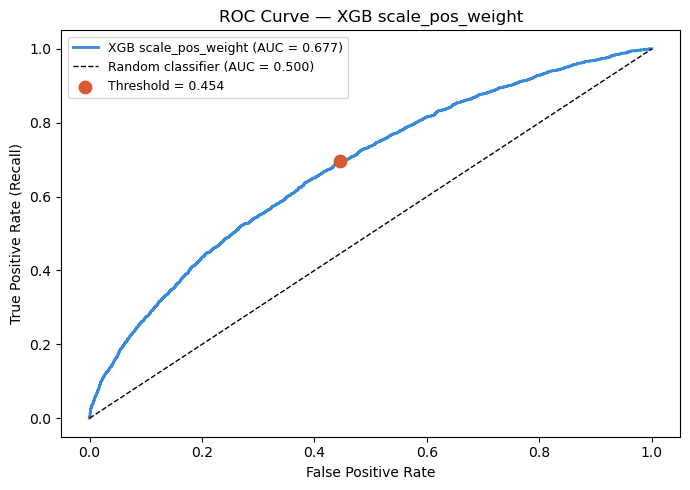

In [5]:
evaluation.plot_roc_curve(
    y_test, probs, threshold=best_thresh,
    model_label="XGB scale_pos_weight",
    save_path=f'{FIGURES_DIR}/roc_curve.png'
)

# Finding - The AUC of ~0.676 means the curve bows moderately above the diagonal — not steeply,
# which reflects the weak signal in the available features.

## SHAP — feature importance and direction

In [6]:
# ── 1. Extract the fitted XGBoost model and preprocessor from the pipeline ──
xgb_model = xgb_model_pipeline.named_steps['xgbclassifier']
preprocessor_step = xgb_model_pipeline.named_steps['preprocessor']

# ── 2. Get the transformed test data (after preprocessing) ──
X_test_transformed = preprocessor_step.transform(X_test)

# ── 3. Reconstruct feature names after one-hot encoding (see src.evaluation.get_feature_names_out) ──
all_feature_names = evaluation.get_feature_names_out(preprocessor_step, cat_cols)

# ── 4. Create SHAP explainer ──
explainer = shap.TreeExplainer(xgb_model)

# Subsample for speed — 2000 rows is sufficient for stable SHAP values
X_sample = X_test_transformed[:2000]
shap_values = explainer.shap_values(X_sample)

X_sample_df = pd.DataFrame(X_sample, columns=all_feature_names)

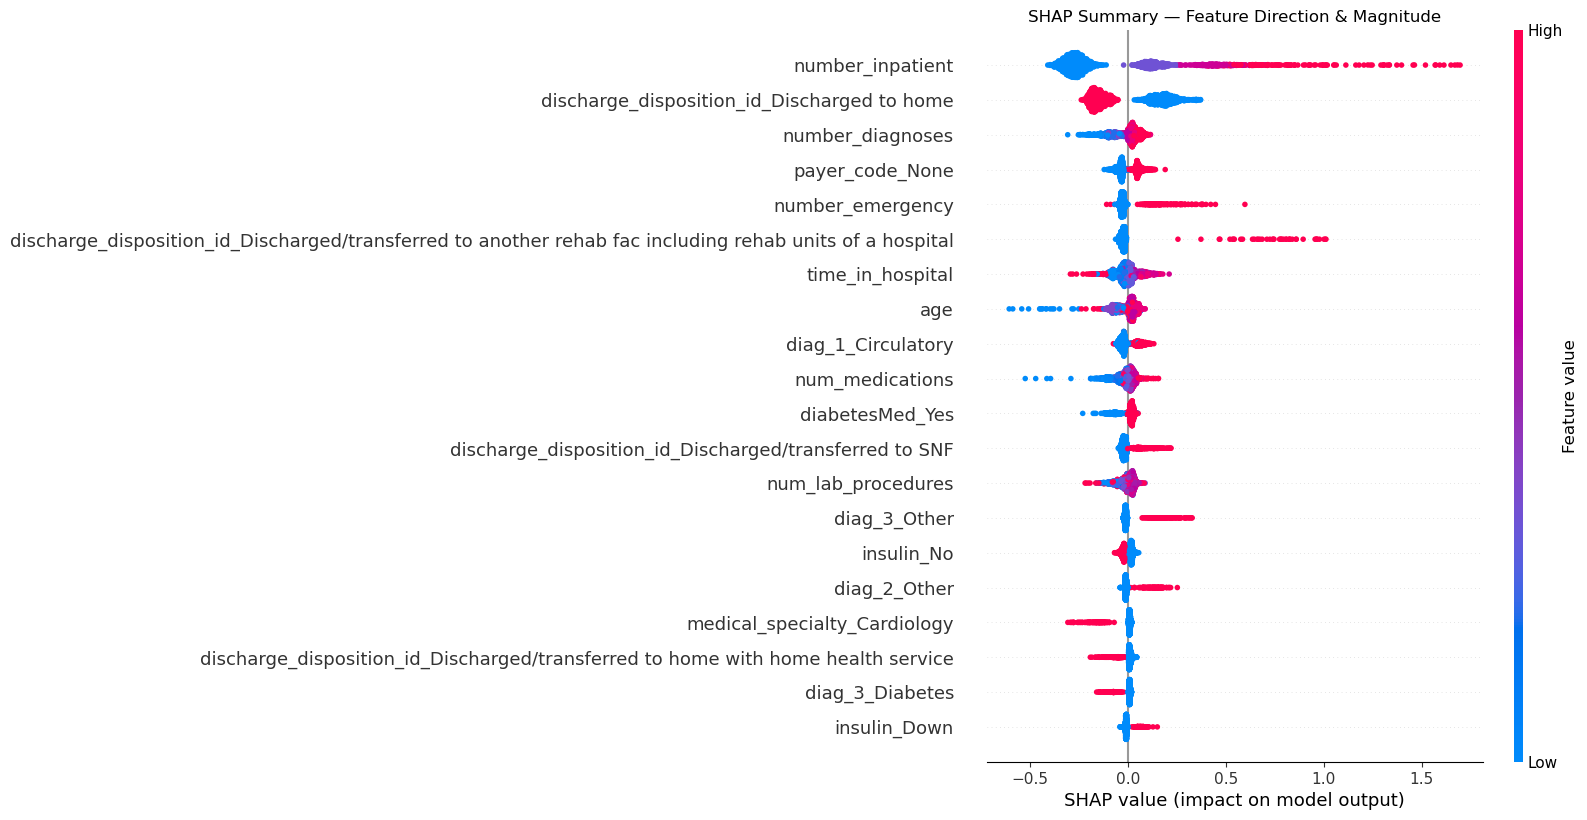

In [7]:
# PLOT: Beeswarm — direction + magnitude per feature
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample_df, show=False)
plt.title("SHAP Summary — Feature Direction & Magnitude")
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/shap_beeswarm.png', dpi=150, bbox_inches="tight")
plt.show()

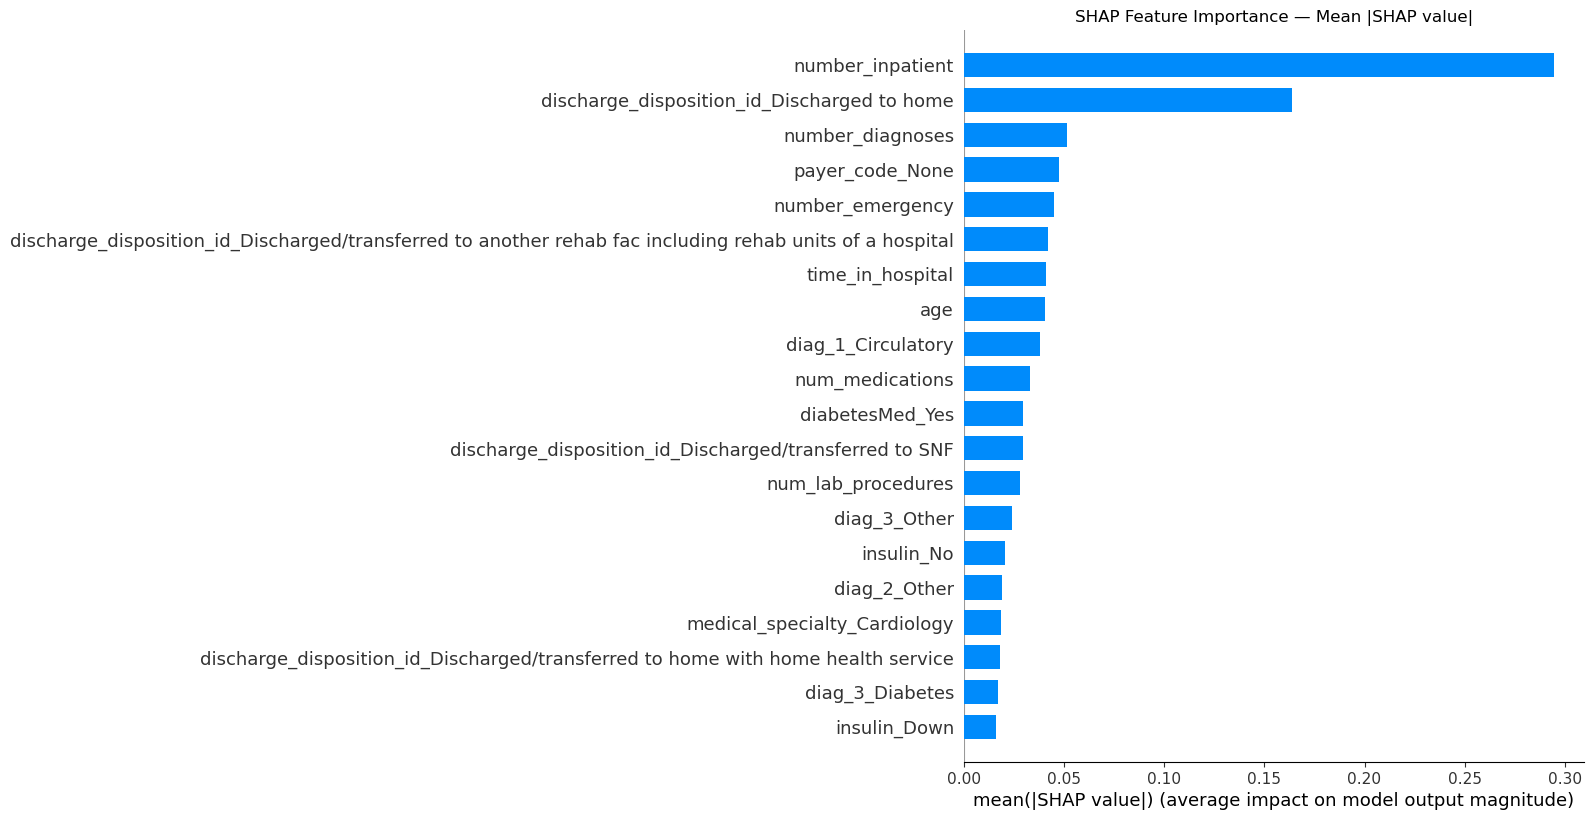

In [8]:
# PLOT: Bar — mean |SHAP value| ranking of top features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample_df, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Mean |SHAP value|")
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/shap_bar.png', dpi=150, bbox_inches="tight")
plt.show()

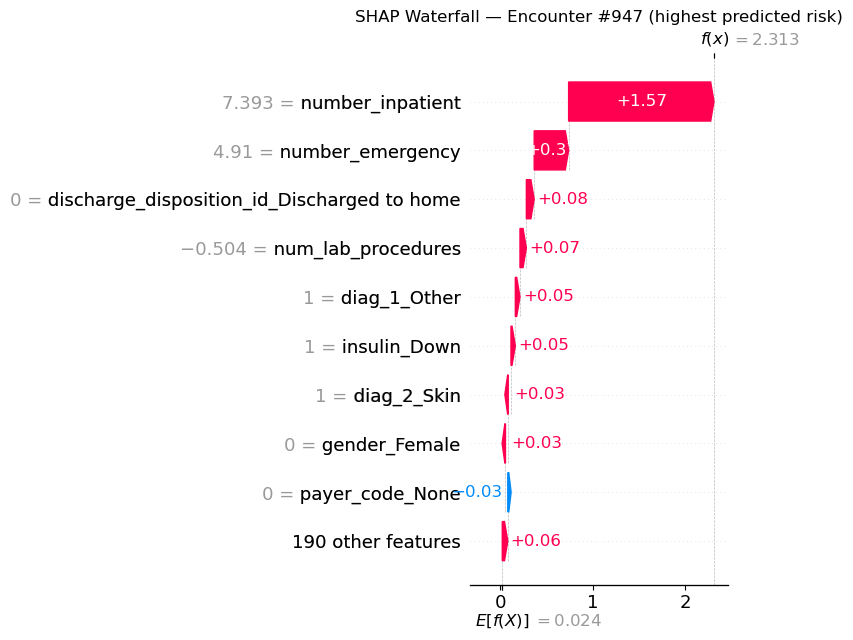

In [9]:
# PLOT: Waterfall — how a single high-risk patient's prediction is built up from the base rate
sample_idx = int(np.argmax(shap_values.sum(axis=1)))

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_sample_df.iloc[sample_idx],
    feature_names=all_feature_names,
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Waterfall — Encounter #{sample_idx} (highest predicted risk)")
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/shap_waterfall.png', dpi=150, bbox_inches="tight")
plt.show()

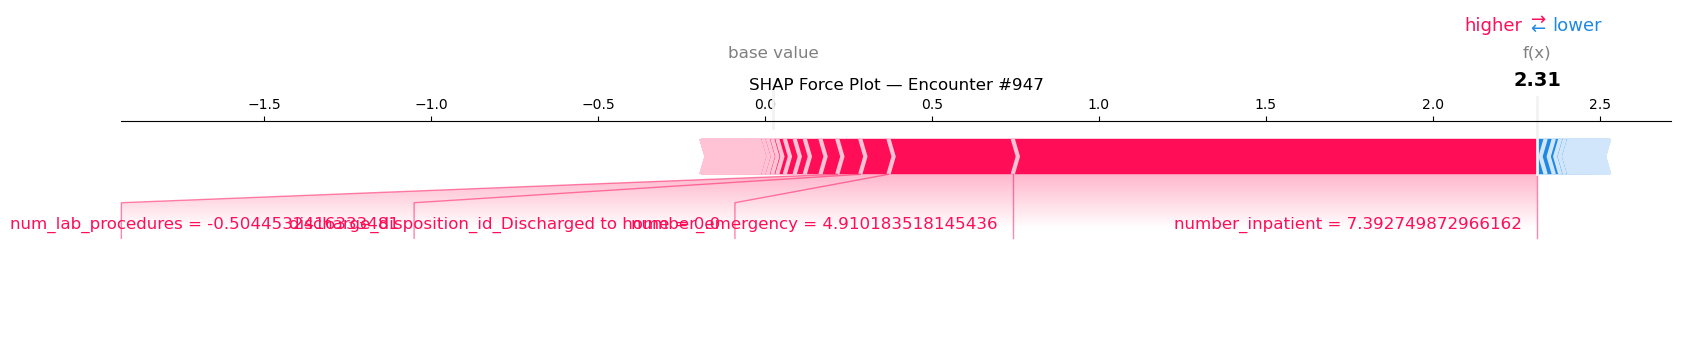

In [10]:
# PLOT: Force plot — same encounter, showing features pushing risk up (red) vs down (blue)
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_sample_df.iloc[sample_idx],
    matplotlib=True,
    show=False,
)
plt.title(f"SHAP Force Plot — Encounter #{sample_idx}")
plt.savefig(f'{FIGURES_DIR}/shap_force_plot.png', dpi=150, bbox_inches="tight")
plt.show()

#### Finding:
**Most important features**
- **number_inpatient**\
   The single strongest predictor, SHAP values reach up to +1.7. Pink dots (high inpatient count) spread far right, meaning more prior inpatient visits strongly push readmission risk up. Blue dots (few visits) cluster near zero. Clinically: a patient with multiple recent admissions is a well-established high-risk profile.
-  **discharge_disposition_id**\
  Discharged to home - Red dots (patient WAS discharged home, value=1) push risk DOWN — going home directly is a protective signal. Blue dots (not discharged home) push risk UP. This makes clinical sense: patients sent to rehab or SNF after discharge are sicker and more likely to bounce back.
-  **number_diagnoses**\
  Higher diagnosis count (pink, right side) increases readmission risk. More diagnoses = higher disease burden and complexity. A symmetric spread around zero indicates this feature has both protective and risk-increasing effects depending on severity level.
-  **number_emergency**\
  More emergency visits (pink dots, right) increases risk. Prior ER use is a well-known readmission predictor — patients who frequently use emergency services tend to have poorly controlled chronic conditions.
-  **discharge_disposition**\
   Transferred to rehab/hospital - When a patient is transferred to a rehab facility rather than going home, risk increases significantly — pink dots reach SHAP values above +1.0. These patients are already too unwell to go home, making readmission much more likely.

**Mid-tier features (#6–#13)**
- **time_in_hospital**\
 Longer stays (pink) show a slight risk increase but the effect is small and spread narrow. Shorter stays (blue) can also increase risk discharged too early before stabilisation. The mixed pattern suggests this feature alone is not a strong discriminator.
- **payer_code_Unknown**\
  When payer code is unknown (value=1, red dots), risk decreases slightly. This likely acts as a proxy for patient administrative profile rather than a direct clinical signal — unknown payer may correlate with certain encounter types less likely to result in readmission.
- **diag_1_Circulatory**\
  A primary circulatory diagnosis (heart failure, MI, etc.) increases readmission risk. Pink dots push right. Circulatory conditions are among the highest-risk diagnoses for hospital readmission in the diabetes population.
- **age**
  Blue dots (younger patients) sit right of zero - younger age slightly increases predicted readmission risk. Older patients (pink, left) slightly decrease it. This may be counterintuitive but reflects the dataset composition: very elderly patients may have more complete discharge planning or hospice transitions captured elsewhere.
- **num_medications**
  More medications (pink) slightly decreases readmission risk - patients on more medications may be better managed pharmacologically. However the effect is small and the spread is narrow, making this a weak predictor overall.

**Lower-tier features**
- **diag_3_Other / diag_3_Diabetes / diag_2_Other**
  Secondary and tertiary diagnoses contribute modestly. Diabetes as a third diagnosis (diag_3_Diabetes, red dots left) is protective — it may indicate the primary reason for admission was non-diabetes, suggesting a less acute presentation.
- **discharge to home with home health service**
  Pink dots (discharged with home health, value=1) push left — receiving home health care after discharge is protective, likely because these patients get follow-up support that prevents deterioration leading to readmission.
- **medical_specialty_Cardiology**
  Cardiology patients (red, left) show decreased readmission risk from this feature. Cardiology units may have stronger discharge protocols and follow-up pathways for diabetic patients compared to general medicine.
- **insulin_No / insulin_Down**
  Not being on insulin (insulin_No = 1, red dots left) reduces predicted risk. Patients not requiring insulin likely have less severe diabetes. Insulin being reduced (Down) also slightly lowers risk — possibly indicating improving glycaemic control during the stay.

Overall
Top risk factors - Prior inpatient visits, Emergency visits, Rehab/transfer discharge, Circulatory primary diagnosis, High diagnosis count

Protective factors - Discharged home, Home health service, Cardiology specialty, Not on insulin, Unknown payer code

# Business Impact
**Patient Outcomes**\
At 0.43 threshold, the model catches 75% of 30-day readmissions before they happen — enabling targeted discharge interventions for 1,703 high-risk patients per 20,000 encounters who would otherwise go unidentified.\
**Operational Efficiency**\
Replaces inconsistent clinician judgment with a standardised, automated risk score applied at every discharge. Care coordinators can prioritise the highest-risk patients rather than spreading resources broadly — making finite capacity go further.\
**Explainability**\
SHAP analysis shows why each patient was flagged — prior inpatient visits, discharge destination, emergency history — giving clinicians actionable context, not just a score. This directly improves adoption and trust.\
**Key Caveat for Stakeholders**\
Precision is 16% at the recommended threshold — for every 6 alerts, 1 is a true readmission. This false alarm burden must be weighed against the cost of a missed readmission. The model is a decision-support tool, not an autonomous decision-maker, and requires retraining on recent data before clinical deployment.

# Future Enhancements
**Feature Engineering**
* Interaction between number_inpatient and time_in_hospital, and between medication count and diagnosis count is engineered
* Trend features if patient history across multiple encounters is used (e.g. increasing number of visits over time)
* Review patient_nbr for patients that return frequently

**Better Handling of Rare Categories**
* The current approach fills unknown categories as "Unknown", another approach would be target encoding or frequency encoding for high-cardinality columns like admission_source_id and admission_type_id, which would preserve more information without sparse one-hot columns.